# Gaussian Rays vs Multislice for a Single Atom

Quick comparison of the Gaussian-beam approximation against analytical thin-slice phase shifts and multislice simulations for a single atom, plus a STEM probe variant.


## Environment setup


In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.4"

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp

from temgym_core.components import Detector
from temgym_core.gaussian import (
    AtomicPotential,
    FreeSpacePropagator,
    apply_action_delta,
    circular_input_wave,
    run_to_end_vmapped,
    taylor_expand,
    square_input_wave,
    GaussianBeam,
)
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.potential import Si, potential, potential_smoothed
from temgym_core.utils import FresnelPropagator

jax.config.update("jax_enable_x64", True)

%matplotlib widget


## Smoothed atomic potential

Validate that spline smoothing preserves the potential integral and inspect its 1D/2D shape.


In [2]:
extent = 10.0  # angstrom half-width of the square window
n_px = 256

r_sharp, spacing = np.linspace(-extent, extent, n_px, retstep=True)
r_smooth = np.linspace(-extent, extent, 4 * n_px, retstep=False)

V = potential(np.abs(r_sharp), Si)
V0 = potential(np.abs(jnp.array([spacing / 2])), Si)
V_smooth = potential_smoothed(np.abs(r_smooth), Si, spacing / 3)

V_area = np.trapz(V, x=r_sharp)
V_smooth_area = np.trapz(V_smooth, x=r_smooth)

print(f"pixel spacing = {spacing:.4f} A")
print(f"integral V(r) (raw)     = {V_area:g}")
print(f"integral V(r) (smoothed)= {V_smooth_area:g}")


pixel spacing = 0.0784 A
integral V(r) (raw)     = 25.277
integral V(r) (smoothed)= 25.4991


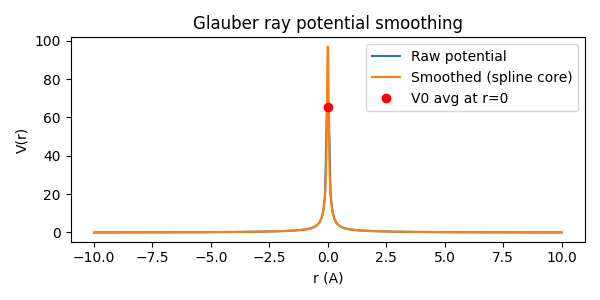

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(r_sharp, V, label="Raw potential")
ax.plot(r_smooth, V_smooth, label="Smoothed (spline core)")
ax.plot(0, abs(V0), "ro", label="V0 avg at r=0")
ax.set_xlabel("r (A)")
ax.set_ylabel("V(r)")
ax.set_title("Glauber ray potential smoothing")
ax.legend()
fig.tight_layout()


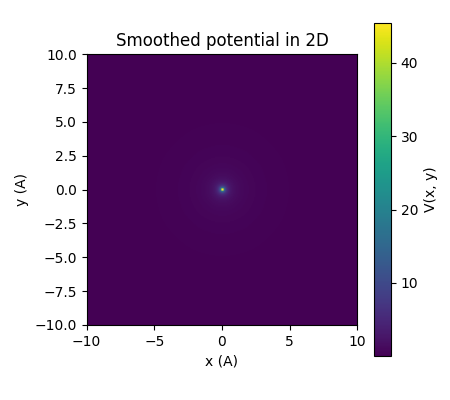

In [4]:
r_plot = np.linspace(-extent, extent, 256)

def radial_potential_xy(x, y):
    r = jnp.sqrt(x**2 + y**2)
    return potential_smoothed(r, Si, spacing / 3)

grid_vals = jax.vmap(
    lambda yy: jax.vmap(lambda xx: radial_potential_xy(xx, yy))(r_plot)
)(r_plot)

plt.figure(figsize=(4.5, 4))
plt.imshow(
    grid_vals,
    extent=(r_plot[0], r_plot[-1], r_plot[0], r_plot[-1]),
    origin="lower",
)
plt.colorbar(label="V(x, y)")
plt.xlabel("x (A)")
plt.ylabel("y (A)")
plt.title("Smoothed potential in 2D")
plt.tight_layout()


## Single slice: Gaussian rays vs analytic phase

Compare the Gaussian-beam solution against the exact thin-slice phase at the atom plane and after free-space propagation.


In [5]:
aperture_length = 25.0
waist = 0.05
voltage = 100e3
propagation = 5.0  # angstrom
overlap_factor = 2.0

detector_at_slice = Detector(
    z=0.0, pixel_size=(spacing, spacing), shape=(n_px, n_px)
)
detector_at_propagation = Detector(
    z=propagation, pixel_size=(spacing, spacing), shape=(n_px, n_px)
)

atom = AtomicPotential(
    atom_xyz=jnp.array([0.0, 0.0, 0.0]),
    element_params=Si,
    cutoff_radius=spacing / 3,
)

rays_in = square_input_wave(
    aperture_length=aperture_length,
    waist=waist,
    voltage=voltage,
    overlap_factor=overlap_factor,
    wavelength_unit="angstrom",
)

print(f"Number of Gaussian beams: {rays_in.r_xy.shape[0]}")

rays_after_slice = run_to_end_vmapped(rays_in, (atom,))
field_after_slice = evaluate_gaussians_gpu_kernel_wrapper(
    rays_after_slice, detector_at_slice
)

rays_after_propagation = run_to_end_vmapped(
    rays_in, (atom, detector_at_propagation)
)
field_after_propagation = evaluate_gaussians_gpu_kernel_wrapper(
    rays_after_propagation, detector_at_propagation
)

sigma = rays_in.sigma[0]
k = rays_in.k[0]
phase_grid = jax.vmap(
    atom.phase_shift, in_axes=(0, None, None, None)
)(detector_at_slice.coords, 0.0, sigma, k).reshape(detector_at_slice.shape)
thin_slice_transmission = jnp.exp(1j * k * phase_grid)


Number of Gaussian beams: 1000000


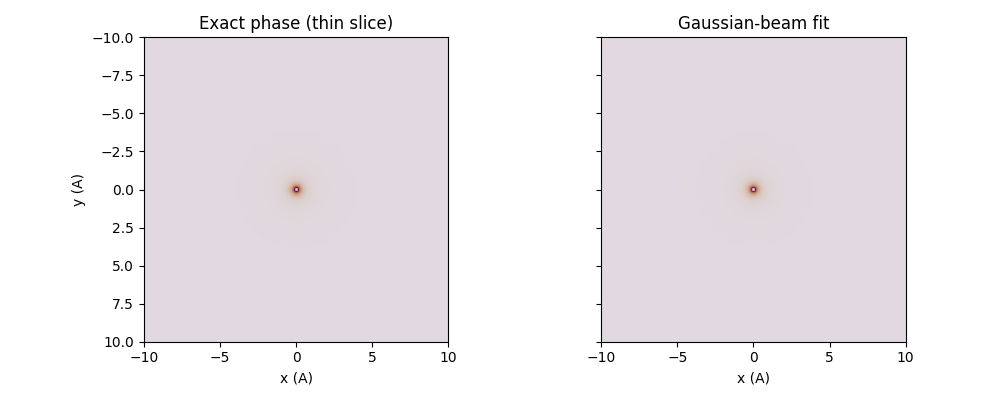

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
im0 = axes[0].imshow(
    jnp.angle(thin_slice_transmission),
    extent=detector_at_slice.extent,
    cmap="twilight",
)
axes[0].set_title("Exact phase (thin slice)")
im1 = axes[1].imshow(
    jnp.angle(field_after_slice),
    extent=detector_at_slice.extent,
    cmap="twilight",
)
axes[1].set_title("Gaussian-beam fit")
for ax in axes:
    ax.set_xlabel("x (A)")
axes[0].set_ylabel("y (A)")
fig.tight_layout()


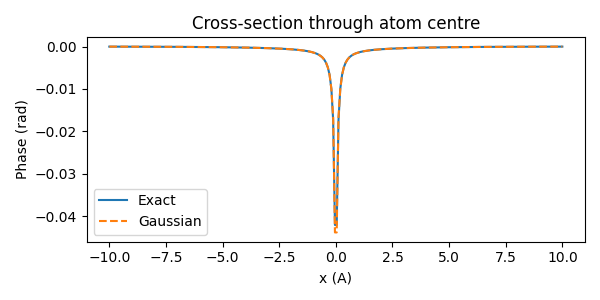

In [7]:
center = detector_at_slice.shape[0] // 2
x_coords = detector_at_slice.coords_1d[0]

plt.figure(figsize=(6, 3))
plt.plot(x_coords, np.angle(thin_slice_transmission[center, :]), label="Exact")
plt.plot(
    x_coords,
    np.angle(field_after_slice[center, :]),
    "--",
    label="Gaussian",
)
plt.xlabel("x (A)")
plt.ylabel("Phase (rad)")
plt.title("Cross-section through atom centre")
plt.legend()
plt.tight_layout()


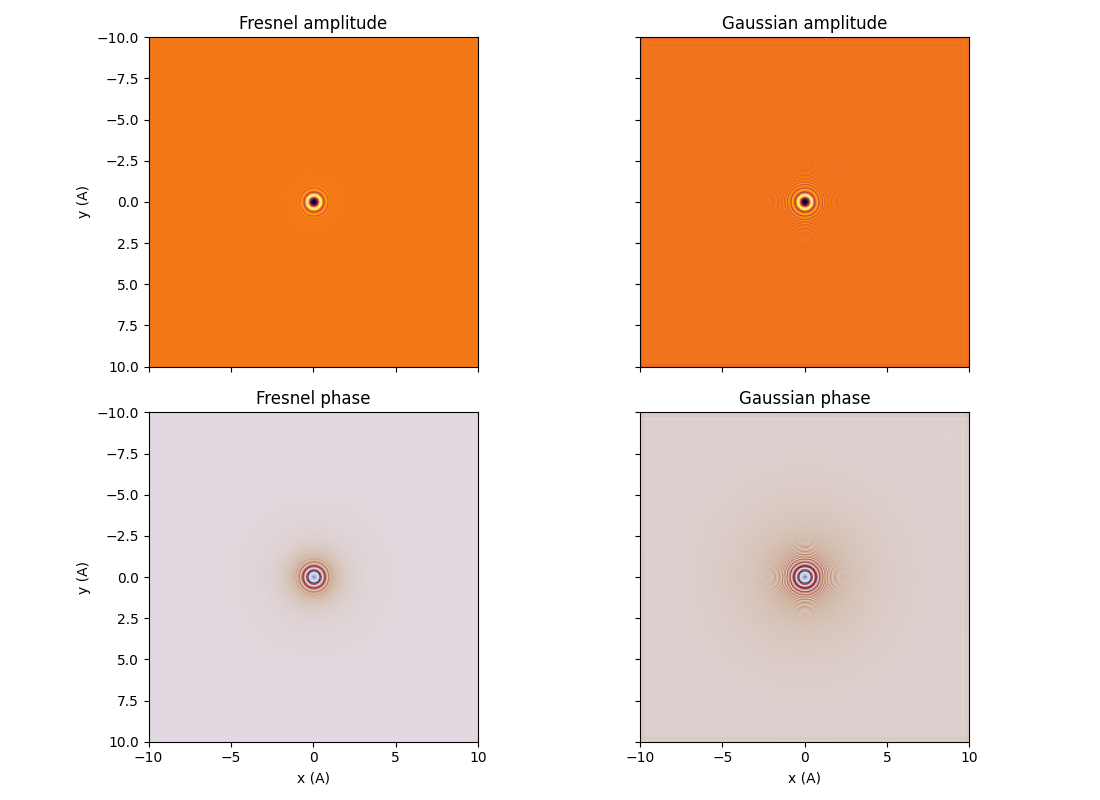

In [8]:
fresnel_field = FresnelPropagator(
    thin_slice_transmission, L=extent * 2, wavelength=rays_in.wavelength[0], z=propagation
)
gaussian_propagated_field = field_after_propagation

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes[0, 0].imshow(jnp.abs(fresnel_field), extent=detector_at_propagation.extent, cmap="inferno")
axes[0, 0].set_title("Fresnel amplitude")
axes[1, 0].imshow(jnp.angle(fresnel_field), extent=detector_at_propagation.extent, cmap="twilight")
axes[1, 0].set_title("Fresnel phase")
axes[0, 1].imshow(jnp.abs(gaussian_propagated_field), extent=detector_at_propagation.extent, cmap="inferno")
axes[0, 1].set_title("Gaussian amplitude")
axes[1, 1].imshow(jnp.angle(gaussian_propagated_field), extent=detector_at_propagation.extent, cmap="twilight")
axes[1, 1].set_title("Gaussian phase")
for ax in axes[-1, :]:
    ax.set_xlabel("x (A)")
for ax in axes[:, 0]:
    ax.set_ylabel("y (A)")
fig.tight_layout()


## Multislice comparison (plane wave vs Gaussian rays)

Build a short stack of potential slices and compare a plane-wave multislice result against the Gaussian-beam ODE with a per-slice kick scaled by the slice thickness.


In [9]:
def build_potential_slices(x, y, z_slices, atom_pos, p, r_cutoff):
    '''
    x: (nx,)
    y: (ny,)
    z_slices: (nz,)
    atom_pos: (n_atoms, 3) in angstrom
    p: potential parameters (e.g. Si)
    r_cutoff: smoothing radius

    returns: V_slices with shape (nz, ny, nx)
    '''
    x = jnp.asarray(x)
    y = jnp.asarray(y)
    z_slices = jnp.asarray(z_slices)
    atom_pos = jnp.asarray(atom_pos)

    X, Y = jnp.meshgrid(x, y, indexing="xy")
    X = X.T
    Y = Y.T

    def slice_at_z(z_k):
        def atom_contrib(atom):
            dx = X - atom[0]
            dy = Y - atom[1]
            dz = z_k - atom[2]
            r = jnp.sqrt(dx * dx + dy * dy + dz * dz)
            return potential_smoothed(r, p, r_cutoff)

        return jnp.sum(jax.vmap(atom_contrib)(atom_pos), axis=0)

    return jax.vmap(slice_at_z)(z_slices)


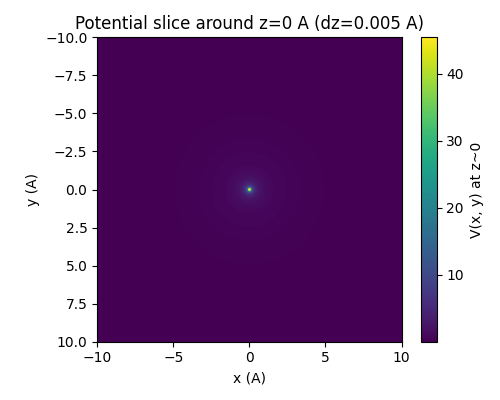

In [10]:
propagation_start = -5.0
propagation_end = 5.0
n_slices = 2000
dz = float((propagation_end - propagation_start) / (n_slices - 1))
z_slices = jnp.linspace(propagation_start, propagation_end, n_slices)

atom_pos = jnp.array([[0.0, 0.0, 0.0]])
x_coords, y_coords = detector_at_slice.coords_1d

V_slices = build_potential_slices(x_coords, y_coords, z_slices, atom_pos, Si, r_cutoff=spacing / 3)

plt.figure(figsize=(5, 4))
plt.imshow(
    V_slices[n_slices // 2],
    extent=(x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]),
    origin="lower",
)
plt.colorbar(label="V(x, y) at z~0")
plt.title(f"Potential slice around z=0 A (dz={dz:.3f} A)")
plt.xlabel("x (A)")
plt.ylabel("y (A)")
plt.tight_layout()


In [11]:
# Plane-wave multislice
psi = jnp.ones((detector_at_slice.shape[0], detector_at_slice.shape[1]), dtype=jnp.complex128)
wavelength_ms = rays_in.wavelength[0]
sigma_ms = rays_in.sigma[0]

for idx, V_slice in enumerate(V_slices):
    phase = -V_slice * dz * sigma_ms
    psi = psi * jnp.exp(1j * phase)
    if idx < len(V_slices) - 1:
        psi = FresnelPropagator(psi, L=extent * 2, wavelength=wavelength_ms, z=dz)

multislice_output_field = psi


In [14]:
def atomic_kick_with_thickness(ray: GaussianBeam, atom, dz):
    dS0, dS1, dS2 = taylor_expand(
        atom.complex_action, ray.r_xy, ray.z, ray.sigma, ray.k
    )

    r_xy, d_xy, amplitude, pathlength, Q_new = apply_action_delta(
        ray,
        dS0=dS0 * dz,
        dS1=dS1 * dz,
        dS2=dS2 * dz,
    )

    return ray.derive(
        x=r_xy[0],
        y=r_xy[1],
        dx=d_xy[0],
        dy=d_xy[1],
        amplitude=amplitude,
        pathlength=pathlength,
        Q_inv=Q_new,
    )


In [15]:
# Gaussian-beam multislice with per-slice kick scaled by dz
detector_at_exit = Detector(z=propagation_end, pixel_size=(spacing, spacing), shape=(n_px, n_px))

propagator = FreeSpacePropagator()
prop_step = jax.jit(jax.vmap(propagator, in_axes=(0, None)))
atom_step = jax.jit(jax.vmap(lambda r: atomic_kick_with_thickness(r, atom, dz), in_axes=(0,)))

rays_ms = square_input_wave(
    aperture_length=aperture_length * 2,
    waist=wavelength_ms * 3,
    voltage=voltage,
    overlap_factor=overlap_factor,
    wavelength_unit="angstrom",
    z0=propagation_start,
)

ray = rays_ms
for idx in range(len(z_slices)):
    ray = atom_step(ray)
    if idx < len(z_slices) - 1:
        ray = prop_step(ray, dz)

ray_after_multislice = ray
field_after_multislice = evaluate_gaussians_gpu_kernel_wrapper(ray_after_multislice, detector_at_exit).block_until_ready()


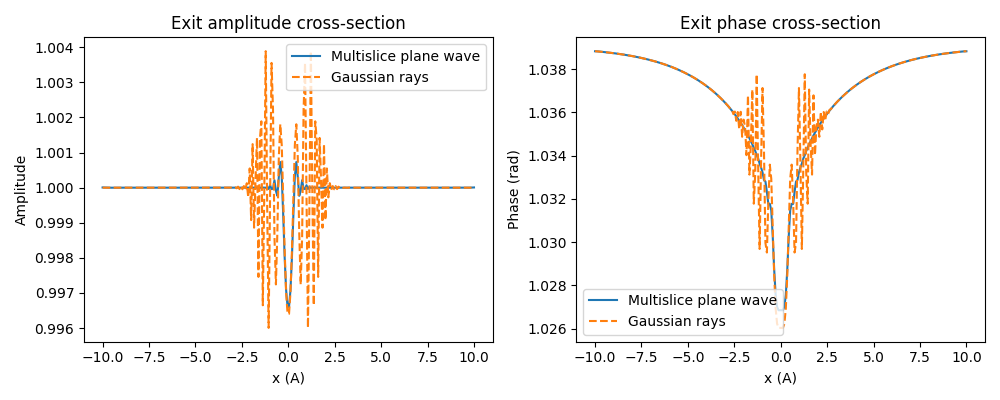

In [16]:
x_coords_exit = detector_at_exit.coords_1d[0]
center_y = detector_at_exit.shape[0] // 2

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_coords_exit, jnp.abs(multislice_output_field[center_y, :]), label="Multislice plane wave")
plt.plot(x_coords_exit, jnp.abs(field_after_multislice[center_y, :]), "--", label="Gaussian rays")
plt.xlabel("x (A)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Exit amplitude cross-section")

plt.subplot(1, 2, 2)
plt.plot(x_coords_exit, jnp.angle(multislice_output_field[center_y, :]), label="Multislice plane wave")
plt.plot(x_coords_exit, jnp.angle(field_after_multislice[center_y, :]), "--", label="Gaussian rays")
plt.xlabel("x (A)")
plt.ylabel("Phase (rad)")
plt.legend()
plt.title("Exit phase cross-section")

plt.tight_layout()


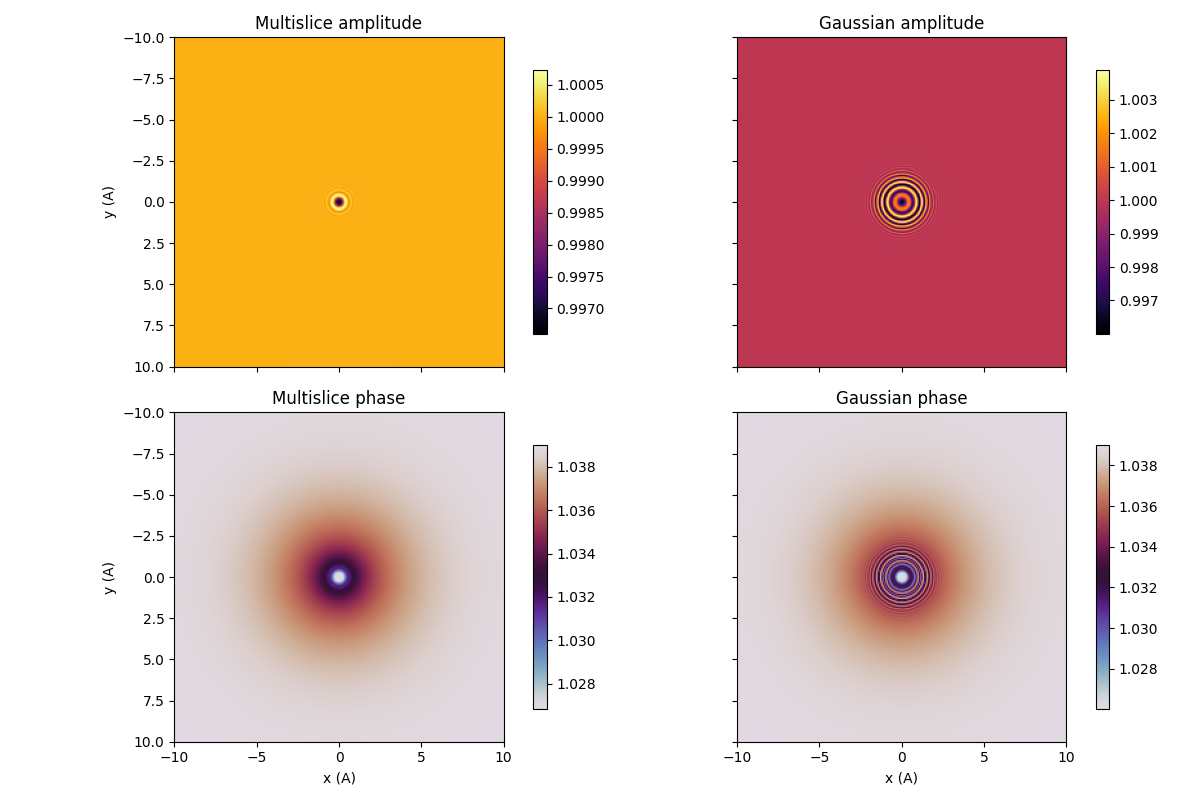

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

im0 = axes[0, 0].imshow(jnp.abs(multislice_output_field), extent=detector_at_exit.extent, cmap="inferno")
axes[0, 0].set_title("Multislice amplitude")
fig.colorbar(im0, ax=axes[0, 0], shrink=0.8)

im1 = axes[1, 0].imshow(jnp.angle(multislice_output_field), extent=detector_at_exit.extent, cmap="twilight")
axes[1, 0].set_title("Multislice phase")
fig.colorbar(im1, ax=axes[1, 0], shrink=0.8)

im2 = axes[0, 1].imshow(jnp.abs(field_after_multislice), extent=detector_at_exit.extent, cmap="inferno")
axes[0, 1].set_title("Gaussian amplitude")
fig.colorbar(im2, ax=axes[0, 1], shrink=0.8)

im3 = axes[1, 1].imshow(jnp.angle(field_after_multislice), extent=detector_at_exit.extent, cmap="twilight")
axes[1, 1].set_title("Gaussian phase")
fig.colorbar(im3, ax=axes[1, 1], shrink=0.8)

for ax in axes[-1, :]:
    ax.set_xlabel("x (A)")
for ax in axes[:, 0]:
    ax.set_ylabel("y (A)")

fig.tight_layout()


## STEM probe: circular aperture

Switch to a convergent probe built from a circular aperture and focus it with a thin lens.


In [18]:
output_pixel_size = spacing
wavelength = rays_in.wavelength[0]
lens_f = 1e-4 * 1e10
aperture_window_width = float(wavelength) * abs(lens_f) / output_pixel_size

rays_in_for_probe = circular_input_wave(
    voltage=voltage,
    aperture_radius=aperture_window_width / 12,
    waist=1e-8 * 1e10,
    z0=0.0,
    wavelength_unit="angstrom",
)

input_circular_aperture_detector = Detector(
    z=0.0,
    pixel_size=(aperture_window_width / n_px, aperture_window_width / n_px),
    shape=(n_px, n_px),
)
input_aperture_field = evaluate_gaussians_gpu_kernel_wrapper(rays_in_for_probe, input_circular_aperture_detector)


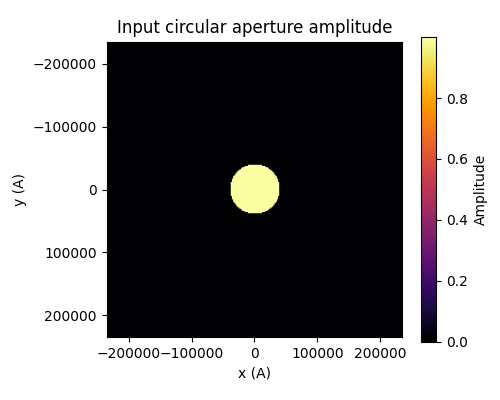

In [19]:
plt.figure(figsize=(5, 4))
plt.imshow(jnp.abs(input_aperture_field), extent=input_circular_aperture_detector.extent, origin="lower", cmap="inferno")
plt.xlabel("x (A)")
plt.ylabel("y (A)")
plt.title("Input circular aperture amplitude")
plt.colorbar(label="Amplitude")
plt.tight_layout()


In [20]:
from temgym_core.gaussian import Lens

lens = Lens(z=lens_f, focal_length=lens_f)
detector_at_input = Detector(z=2 * lens_f, pixel_size=(output_pixel_size, output_pixel_size), shape=(n_px, n_px))
components = (lens, detector_at_input)
rays_out_for_probe = run_to_end_vmapped(rays_in_for_probe, components)


In [21]:
probe_image = evaluate_gaussians_gpu_kernel_wrapper(rays_out_for_probe, detector_at_input).block_until_ready()


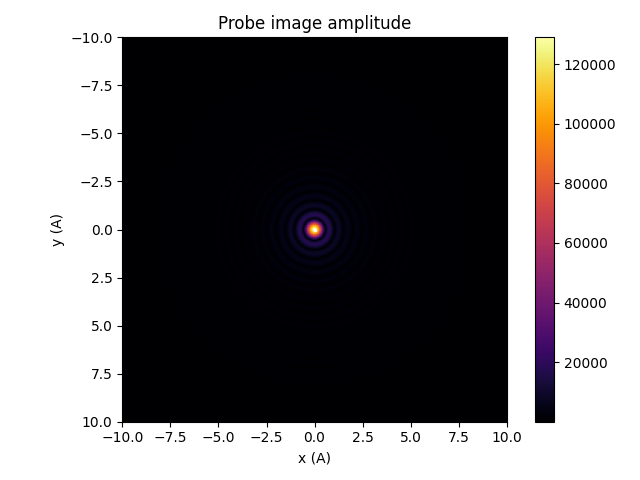

In [22]:
plt.figure()
plt.imshow(jnp.abs(probe_image), extent=detector_at_input.extent, cmap="inferno")
plt.plot(rays_out_for_probe.x, rays_out_for_probe.y, "w.", markersize=1)
plt.colorbar()
plt.title("Probe image amplitude")
plt.xlabel("x (A)")
plt.ylabel("y (A)")
plt.tight_layout()


## STEM multislice comparison


In [23]:
# Plane-wave multislice seeded with the probe image
psi = probe_image
wavelength_ms = rays_in.wavelength[0]
sigma_ms = rays_in.sigma[0]

for idx, V_slice in enumerate(V_slices):
    phase = -V_slice * dz * sigma_ms
    psi = psi * jnp.exp(1j * phase)
    if idx < len(V_slices) - 1:
        psi = FresnelPropagator(psi, L=extent * 2, wavelength=wavelength_ms, z=dz)

multislice_output_field = psi


In [24]:
# Gaussian-beam multislice starting from the STEM probe
detector_at_exit = Detector(z=propagation_end, pixel_size=(spacing, spacing), shape=(n_px, n_px))

propagator = FreeSpacePropagator()
prop_step = jax.jit(jax.vmap(propagator, in_axes=(0, None)))
atom_step = jax.jit(jax.vmap(lambda r: atomic_kick_with_thickness(r, atom, dz), in_axes=0))

rays_ms = rays_out_for_probe.derive(z=jnp.ones_like(rays_out_for_probe.z) * propagation_start)

ray = rays_ms
for idx in range(len(z_slices)):
    ray = atom_step(ray)
    if idx < len(z_slices) - 1:
        ray = prop_step(ray, dz)

ray_after_stem_multislice = ray
field_after_stem_multislice = evaluate_gaussians_gpu_kernel_wrapper(ray_after_stem_multislice, detector_at_exit).block_until_ready()


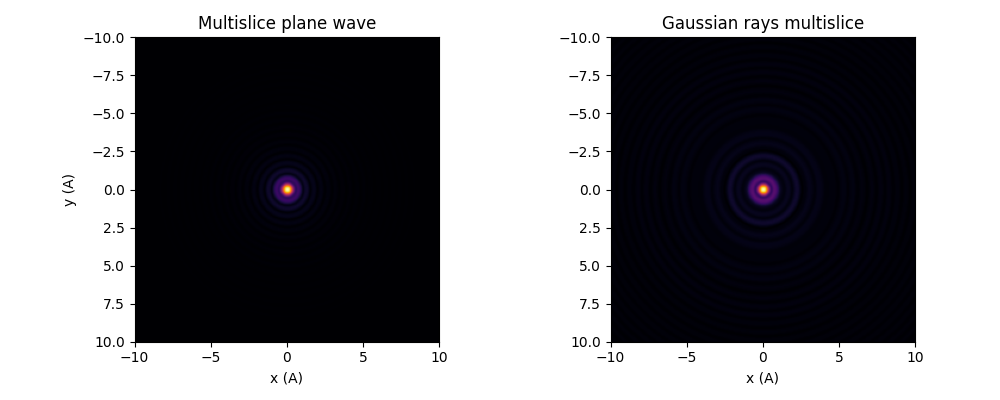

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(jnp.abs(multislice_output_field), extent=detector_at_input.extent, cmap="inferno")
axs[0].set_title("Multislice plane wave")
axs[1].imshow(jnp.abs(field_after_stem_multislice), extent=detector_at_input.extent, cmap="inferno")
axs[1].set_title("Gaussian rays multislice")
for ax in axs:
    ax.set_xlabel("x (A)")
axs[0].set_ylabel("y (A)")
plt.tight_layout()


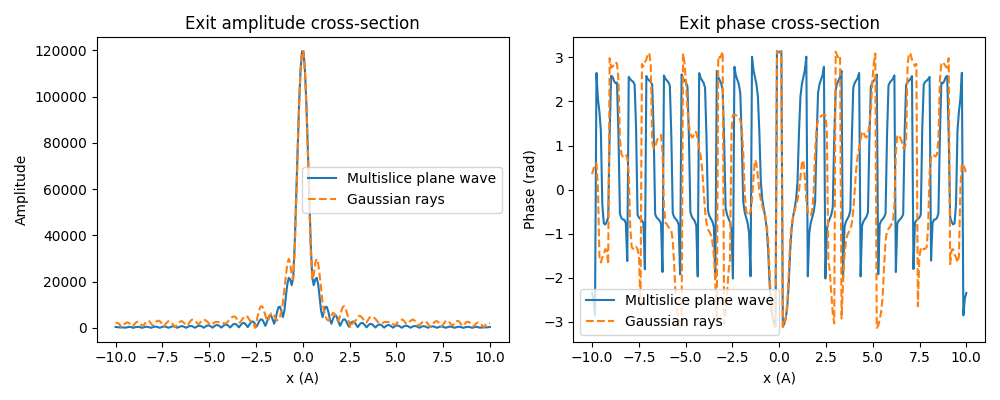

In [26]:
x_coords_exit = detector_at_exit.coords_1d[0]
center_y = detector_at_exit.shape[0] // 2

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_coords_exit, jnp.abs(multislice_output_field[center_y, :]), label="Multislice plane wave")
plt.plot(x_coords_exit, jnp.abs(field_after_stem_multislice[center_y, :]), "--", label="Gaussian rays")
plt.xlabel("x (A)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Exit amplitude cross-section")

plt.subplot(1, 2, 2)
plt.plot(x_coords_exit, jnp.angle(multislice_output_field[center_y, :]), label="Multislice plane wave")
plt.plot(x_coords_exit, jnp.angle(field_after_stem_multislice[center_y, :]), "--", label="Gaussian rays")
plt.xlabel("x (A)")
plt.ylabel("Phase (rad)")
plt.legend()
plt.title("Exit phase cross-section")

plt.tight_layout()
